Data Loading and Inspection

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/q1_heart_disease.csv")

# Shape
print("Shape of dataset:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# First 5 rows
df.head()

Shape of dataset: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


Exploratory Data Analysis

Target Distribution

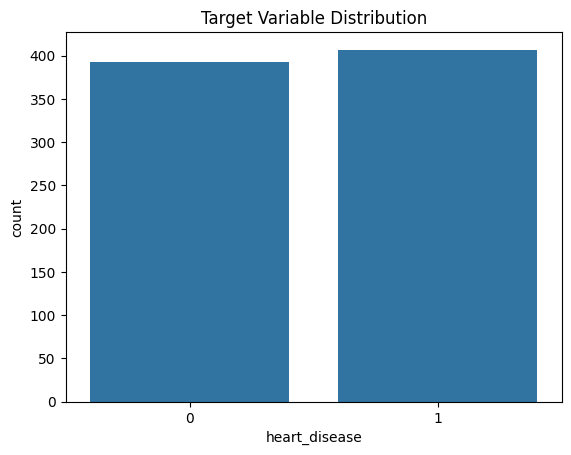

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='heart_disease', data=df)
plt.title("Target Variable Distribution")
plt.show()

Correlation Heatmap

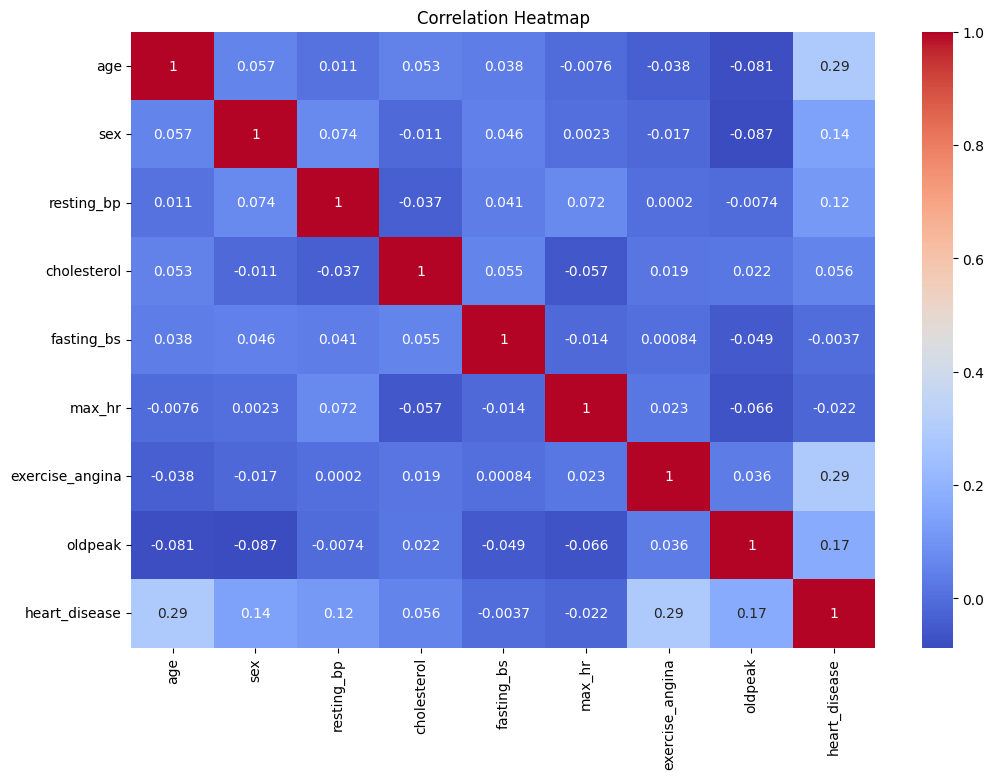

In [6]:
plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include=['number']).corr(), 
            annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Age vs Heart Disease

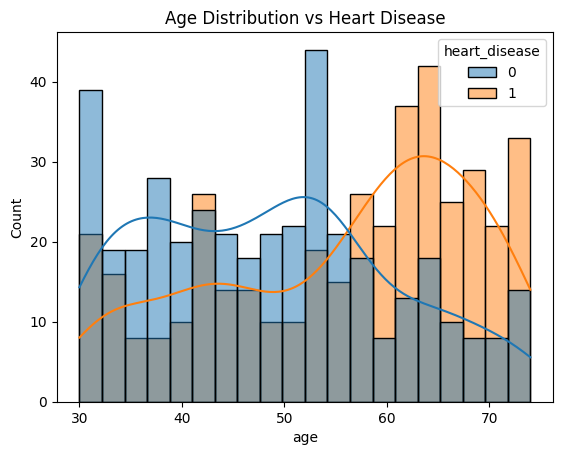

In [5]:
sns.histplot(data=df, x="age", hue="heart_disease", bins=20, kde=True)
plt.title("Age Distribution vs Heart Disease")
plt.show()

Data Preprocessing

Handle Missing Values

In [7]:
# Fill numerical columns with median
df.fillna(df.median(numeric_only=True), inplace=True)

One-Hot Encoding

In [8]:
df = pd.get_dummies(df, drop_first=True)

Feature Scaling + Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split features and target
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model Training

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Train
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Model Evaluation

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

# Evaluation function
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    
    print(f"\n{name} Evaluation:")
    
    # Confusion Matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # Classification Report
    print("\nPrecision, Recall, F1-score:")
    print(classification_report(y_test, y_pred))

# Evaluate all models
evaluate_model(dt, "Decision Tree")
evaluate_model(rf, "Random Forest")
evaluate_model(gb, "Gradient Boosting")


Decision Tree Evaluation:
Confusion Matrix:
[[57 22]
 [25 56]]

Precision, Recall, F1-score:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


Random Forest Evaluation:
Confusion Matrix:
[[61 18]
 [15 66]]

Precision, Recall, F1-score:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting Evaluation:
Confusion Matrix:
[[61 18]
 [19 62]]

Precision, Recall, F1-score:
              precision    recall  f1-score   support

     

In [12]:
evaluate_model(gb, "Gradient Boosting")


Gradient Boosting Evaluation:
Confusion Matrix:
 [[61 18]
 [19 62]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
